# Incorporating the *field cancerization effect* to improve modeling of untreated cancer growth

Supporting-information notebook. It reproduces the numerical analyses described in the manuscript from the data and reported parameter values included in this repository.


## 1. Environment and reproducibility

All stochastic operations use the fixed seed defined in `scr.methods.RNG_SEED`. Model functions and plotting routines are kept in importable modules so that this notebook remains a concise, executable record of the analysis.


In [1]:
from importlib.metadata import version

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy

from scr import data, methods

print({
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "seed": methods.RNG_SEED,
})


{'numpy': '2.5.2', 'pandas': '2.3.3', 'scipy': '1.18.0', 'matplotlib': '3.11.1', 'seed': 20260814}


## 2. Breast-cancer observations

The principal dataset comprises 13 measurements over days 1–13. Volume is expressed in cm³ and converted internally to cancer-cell population using the stated density of $10^7$ cells/cm³ when solving the models.


In [2]:
breast_data, _, _ = data.load_breast_data()
breast_data


,time,volume
0,1.0,0.40
1,2.0,0.65
2,3.0,0.79
3,4.0,0.93
4,5.0,1.06
5,6.0,1.21
6,7.0,1.39
7,8.0,1.57
8,9.0,1.85
9,10.0,2.21


## 3. Mathematical formulations

The implementation contains the original and reparameterized versions of both models:

- Baseline: $dC/dt=rC(1-C/K)-aK_TC+\lambda_{ST}C/2$.
- Reparameterized baseline: $dC/dt=m_1C-m_2C^2$.
- Extended FCE: the baseline equation plus $\lambda_NN$, with $dN/dt=\gamma'C-\gamma N$.
- Reparameterized FCE: $dC/dt=m_1C-m_2C^2+\lambda_NN$ and the same equation for $N$.

The original parameterizations are structurally redundant. They are retained only to reproduce the comparisons in the manuscript; inference should use the reparameterized forms.


In [3]:
reported_parameters = pd.DataFrame({
    "parameter": data.PARAMETER_SYMBOLS,
    "estimate": data.EXTENDED_INITIAL_PARAMS,
    "lower": data.EXTENDED_INITIAL_INTERVALS[:, 0],
    "upper": data.EXTENDED_INITIAL_INTERVALS[:, 1],
    "unit": data.PARAMETER_UNITS,
})
reported_parameters


,parameter,estimate,lower,upper,unit
0,r,3.913000e-01,3.910000e-01,3.916000e-01,day^-1
1,1/K,6.666667e-09,6.666667e-09,6.666667e-09,cell^-1
2,aK_T,1.675000e+00,1.670000e+00,1.680000e+00,day^-1
3,lambda_ST,1.183500e+00,1.181000e+00,1.186000e+00,day^-1
4,lambda_N,2.116200e+00,2.116000e+00,2.116400e+00,day^-1
5,gamma,1.824000e+00,1.821000e+00,1.827000e+00,day^-1
6,gamma_prime,8.135000e-01,8.130000e-01,8.140000e-01,day^-1


## 4. Breast-cancer comparison and admissible parameter sampling

The green region is computed from trajectories sampled uniformly from the reported admissible parameter intervals. It is not labeled as a confidence or prediction interval because no probabilistic coverage statement has been established.


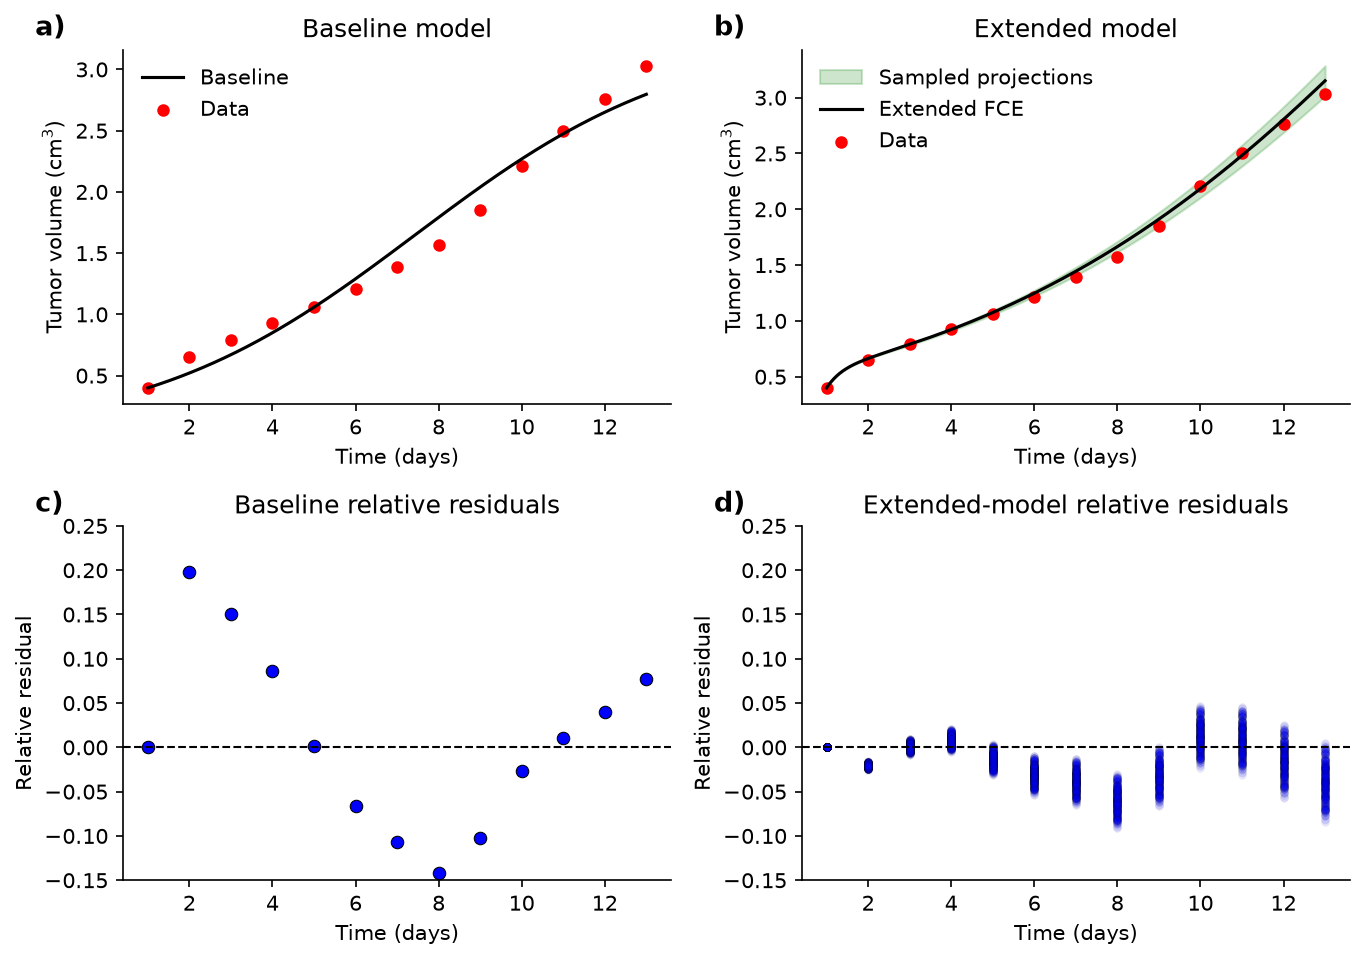

In [4]:
figure_3 = methods.plot_breast_comparison(sample_count=300)
plt.show()


### Relative residuals and information criteria

RSS, MSE, AIC, and BIC follow equations (10)–(13) of the manuscript. All four models use the same 13 observations and response scale.


In [5]:
comparison = methods.model_comparison_table()
comparison.round({"RSS": 6, "MSE": 6, "AIC": 2, "BIC": 2})


,k,RSS,MSE,AIC,BIC
Model,,,,,
Baseline (original),4,0.221337,0.017026,-44.95,-42.69
Baseline (reparameterized),2,0.221337,0.017026,-48.95,-47.82
Extended FCE (initial),7,0.035517,0.002732,-62.74,-58.78
Extended FCE (reparameterized),5,0.039735,0.003057,-65.28,-62.45


### Audit against manuscript Table 5

The manuscript values are compared explicitly with the values recomputed from the dataset declared in the Methods section ($V(1)=0.40$ cm³). A nonzero difference identifies a manuscript–data inconsistency rather than an execution failure.


In [6]:
manuscript_table_5 = pd.DataFrame(
    {
        "MSE": [0.017173, 0.017173, 0.002860, 0.003184],
        "AIC": [-44.84, -48.84, -62.14, -64.74],
        "BIC": [-42.58, -47.71, -58.18, -61.92],
    },
    index=comparison.index,
)
comparison[["MSE", "AIC", "BIC"]].round(6) - manuscript_table_5


,MSE,AIC,BIC
Model,,,
Baseline (original),-0.000147,-0.109248,-0.109451
Baseline (reparameterized),-0.000147,-0.109248,-0.109349
Extended FCE (initial),-0.000128,-0.595182,-0.600537
Extended FCE (reparameterized),-0.000127,-0.536048,-0.531301


## 5. Exploratory cross-cancer analysis

The following plots reproduce the six independently parameterized trajectories. These heterogeneous datasets assess descriptive flexibility only; they do not validate a universal biological mechanism or a common parameter set.

**Units:** every panel is displayed in mm³. The five non-breast spreadsheets are already used in their reported mm³ scale. Breast observations are stored in cm³ and multiplied by 1000; the breast model state is converted from cells using $V_{mm^3}=C/10^7	imes1000$. The legacy reported fits for the five non-breast datasets still operate directly on their volume scales, so the manuscript's statement that every dataset was converted to cell counts must be clarified before submission.


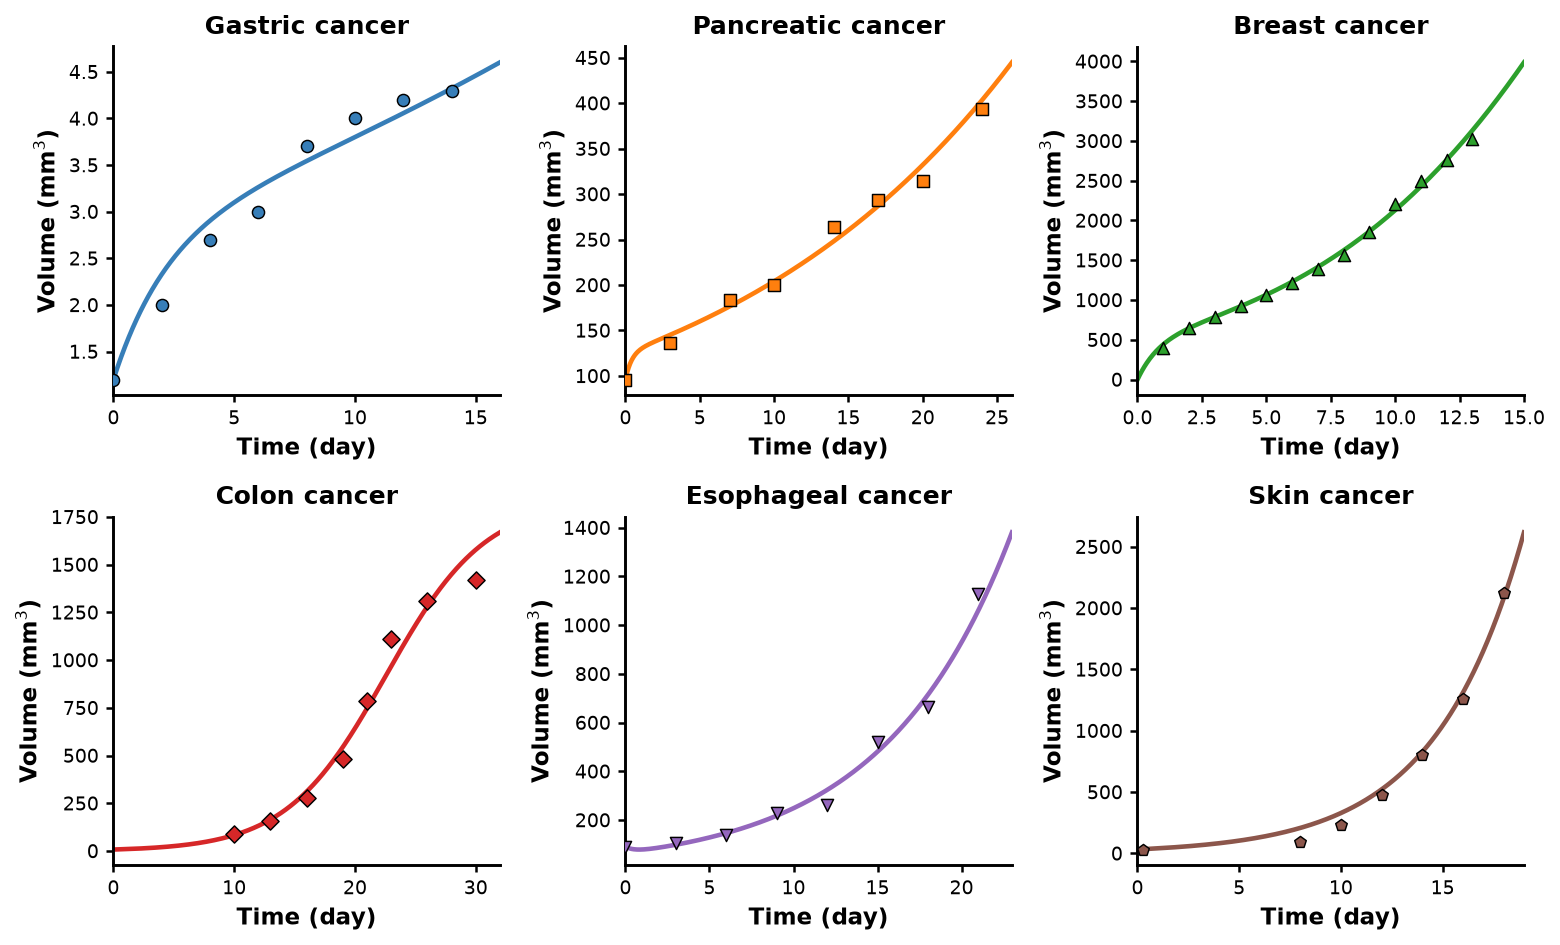

In [7]:
figure_4 = methods.plot_cross_cancer()
plt.show()


## 6. Initial-condition scenarios

This reproduces manuscript Figure 5. The left panel shows the four reported fits when the initial time is fixed at the first observation. The right panel uses the shared reported kinetic parameters and the estimated initial time $t_0=-0.2162$ day. These are reported fitted values, not a new optimization performed by this notebook.


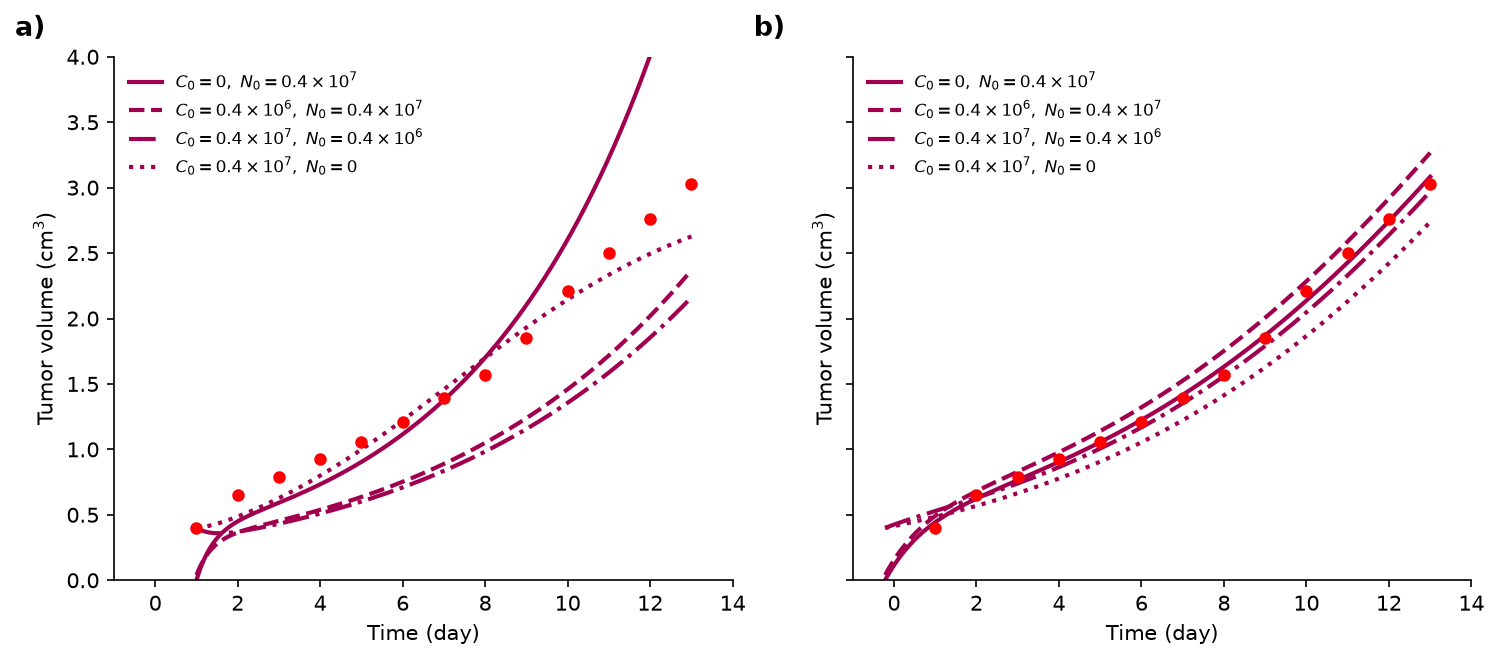

In [8]:
figure_initial_conditions = methods.plot_initial_condition_scenarios()
plt.show()


## 7. Numerical fitting API

`methods.fit_model` provides seeded basin hopping with bounded L-BFGS-B local minimization. 

In [9]:
# Example configuration (not run automatically):
# result = methods.fit_model(
#     methods.extended_reparam_rhs,
#     initial_guess=data.EXTENDED_REPARAM_PARAMS,
#     bounds=[(-2.0, 1.0), (0.0, 1e-7), (0.0, 5.0), (0.0, 5.0), (0.0, 5.0)],
#     initial=data.BREAST_INITIAL_CONDITIONS,
#     niter=100,
# )
print("Seeded fitting API available as methods.fit_model")


Seeded fitting API available as methods.fit_model


## 8. Scope of reproduction

Successful execution verifies that the stored data can be loaded, all four breast-model formulations can be integrated, the reported metrics can be recomputed, and the three analysis figures can be generated. It does not by itself establish biological validity, practical identifiability, or statistical confidence coverage.
